## 😊 Emotion Detection from Text using NLP & Machine Learning

Welcome! In this notebook, we'll build an end-to-end **Emotion Detection System** that predicts the emotion behind a piece of text using traditional NLP techniques and Machine Learning.

### 🎯 Objectives
- Load and explore the dataset
- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess text
- Convert text into numerical features using TF-IDF
- Train and compare multiple ML models
- Evaluate model performance
- Save the best model for deployment in a Streamlit web application

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(
    "../data/train.txt",
    sep=";",
    names=["text", "emotion"]
)

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [3]:
print(f"📊 Dataset Shape : {df.shape}")
print(f"📝 Number of Samples : {df.shape[0]}")
print(f"📌 Number of Features : {df.shape[1]}")
print(f"📂 Dataset Information : {df.info()}")
print(f"🔍 Missing Values : {df.isnull().sum()}")
print(f"📊 Emotion Distribution : {df['emotion'].value_counts()}")

📊 Dataset Shape : (16000, 2)
📝 Number of Samples : 16000
📌 Number of Features : 2
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     16000 non-null  str  
 1   emotion  16000 non-null  str  
dtypes: str(2)
memory usage: 1.8 MB
📂 Dataset Information : None
🔍 Missing Values : text       0
emotion    0
dtype: int64
📊 Emotion Distribution : emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


C:\Users\nsree\AppData\Local\Temp\ipykernel_22376\1593507618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


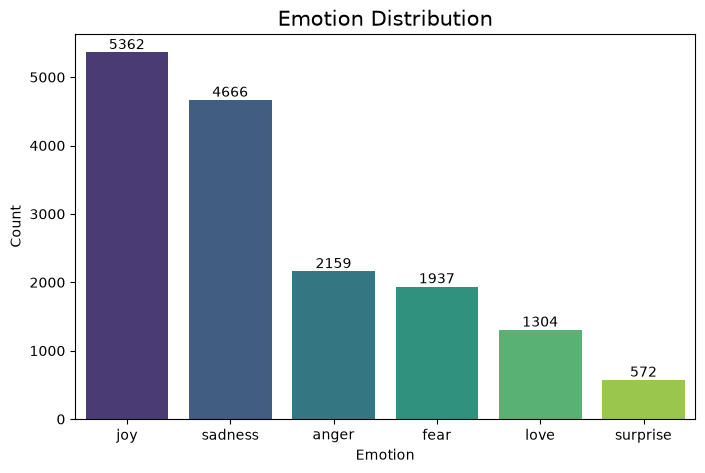

Joy and Sadness are the most frequent emotions.
Surprise has the fewest samples.
The dataset is slightly imbalanced, which may influence the model to favor majority classes.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="emotion",
    order=df["emotion"].value_counts().index,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Emotion Distribution", fontsize=15)
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

print(f"Joy and Sadness are the most frequent emotions.")
print(f"Surprise has the fewest samples.")
print(f"The dataset is slightly imbalanced, which may influence the model to favor majority classes.")

In [5]:
df["text_length"] = df["text"].apply(len)

print(f"📏 Text Length Statistics : {df['text_length'].describe()}")

📏 Text Length Statistics : count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64


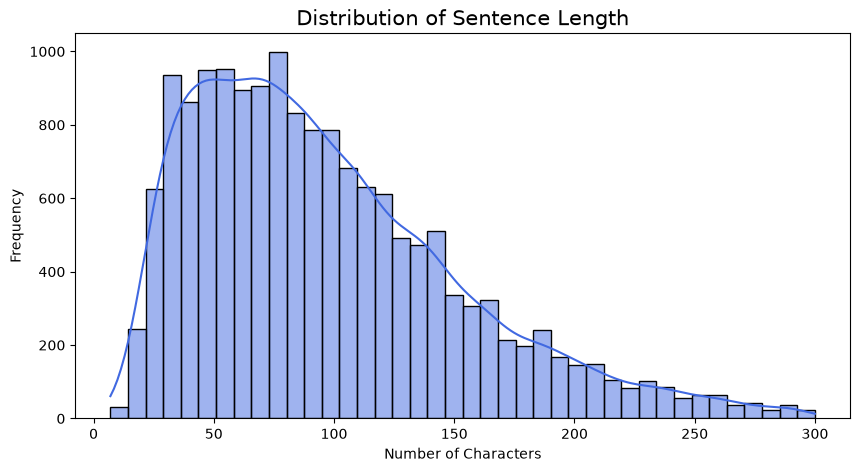

 Most sentences are relatively short.
Average sentence length is 97 characters.
The shortest sentence contains 7 characters.
The longest sentence contains 300 characters.
Most samples lie between 50–130 characters, making this dataset suitable for traditional NLP approaches such as TF-IDF.


In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["text_length"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Sentence Length", fontsize=15)
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()



print(f" Most sentences are relatively short.")
print(f"Average sentence length is 97 characters.")
print(f"The shortest sentence contains 7 characters.")
print(f"The longest sentence contains 300 characters.")
print(f"Most samples lie between 50–130 characters, making this dataset suitable for traditional NLP approaches such as TF-IDF.")

Now we'll clean and preprocess the text before converting it into numerical features for machine learning.

In [ ]:
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Stopwords
stop_words = set(stopwords.words("english"))

# Keep negation words because they change the meaning
negation_words = {
    "not",
    "no",
    "nor",
    "never",
    "don't",
    "doesn't",
    "didn't",
    "can't",
    "couldn't",
    "won't",
    "wouldn't",
    "isn't",
    "aren't",
    "wasn't",
    "weren't",
    "hasn't",
    "haven't",
    "hadn't",
}

stop_words = stop_words - negation_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()

Instead of cleaning the text manually every time, we'll create a reusable function that performs all preprocessing steps automatically.

This function can later be reused during both training and prediction.

In [8]:
#  Building a Text Preprocessing Function
def preprocess_text(text):
    """
    Cleans and preprocesses text for emotion classification.
    """

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    text = text.encode("ascii", "ignore").decode()

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

Before applying preprocessing to the entire dataset, let's test it on a sample sentence to ensure each cleaning step works correctly.

In [9]:
sample = "I am soooo HAPPY!!! 😍😍 Visit https://google.com now!!!"

print("Original Text:")
print(sample)

print("\nCleaned Text:")
print(preprocess_text(sample))

Original Text:
I am soooo HAPPY!!! 😍😍 Visit https://google.com now!!!

Cleaned Text:
soooo happy visit


we'll apply it to every sentence in the dataset.

The cleaned text will be stored in a new column called **clean_text**, which will later be converted into numerical features using TF-IDF.

In [10]:
from tqdm import tqdm

tqdm.pandas()

df["clean_text"] = df["text"].progress_apply(preprocess_text)

100%|██████████| 16000/16000 [00:02<00:00, 7622.43it/s]


In [11]:
df[["text", "clean_text"]].head(10)

,text,clean_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,feeling hopeless damned hopeful around someone...
2,im grabbing a minute to post i feel greedy wrong,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligram time recommended amount i...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas year feel petronas performed well mad...
9,i feel romantic too,feel romantic


In [12]:
df[["text", "clean_text"]].sample(5, random_state=42)

,text,clean_text
8756,ive made it through a week i just feel beaten ...,ive made week feel beaten
4660,i feel this strategy is worthwhile,feel strategy worthwhile
6095,i feel so worthless and weak what does he have...,feel worthless weak say want find
304,i feel clever nov,feel clever nov
8241,im moved in ive been feeling kind of gloomy,moved ive feeling kind gloomy


### Feature Engineering using TF-IDF

Now, we'll use **TF-IDF (Term Frequency - Inverse Document Frequency)** to informative words while reducing the weight of commonly occurring words.

In [13]:
X = df["clean_text"]
y = df["emotion"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (12800,)
Testing Samples  : (3200,)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix :", X_train_tfidf.shape)
print("Testing Matrix  :", X_test_tfidf.shape)

Training Matrix : (12800, 5000)
Testing Matrix  : (3200, 5000)


### Model Training and Evaluation

Instead of relying on a single algorithm, we'll compare multiple classifiers (Multinomial Naive Bayes, Logistic Regression, Support Vector Machine) and evaluate their performance.
And then, we'll select the model with the highest performance for deployment.

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": CalibratedClassifierCV(
        estimator=LinearSVC(random_state=42),
        cv=5
    )
}

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted"),
        "Recall": recall_score(y_test, predictions, average="weighted"),
        "F1 Score": f1_score(y_test, predictions, average="weighted")
    })
    
results_df = (
    pd.DataFrame(results)
      .sort_values(by="Accuracy", ascending=False)
      .reset_index(drop=True)
)

results_df

Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.902188,0.901896,0.902188,0.901949
1,Logistic Regression,0.883437,0.886132,0.883437,0.880621
2,Naive Bayes,0.788750,0.826460,0.788750,0.763390


### Model Evaluation
To better understand the model's performance and evaluate the model for each emotion individually, we'll generate Classification Report and Confusion Matrix

In [18]:
best_model = models["Linear SVM"]

predictions = best_model.predict(X_test_tfidf)
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

       anger       0.91      0.88      0.89       432
        fear       0.89      0.88      0.88       387
         joy       0.91      0.92      0.92      1072
        love       0.80      0.79      0.79       261
     sadness       0.94      0.94      0.94       933
    surprise       0.81      0.78      0.80       115

    accuracy                           0.90      3200
   macro avg       0.88      0.87      0.87      3200
weighted avg       0.90      0.90      0.90      3200



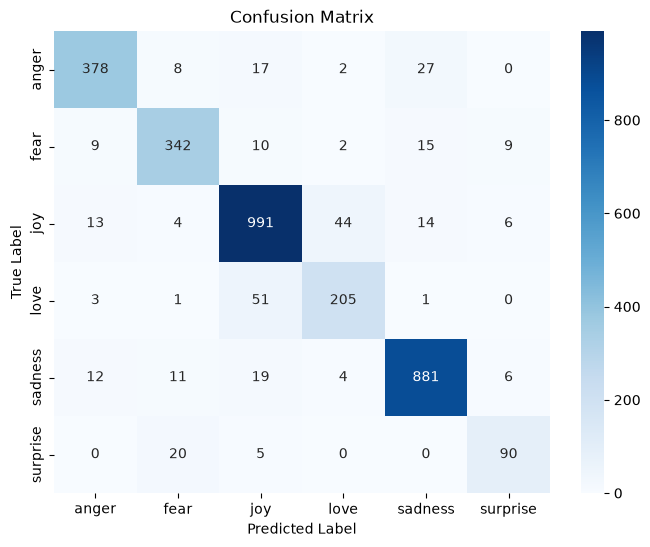

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [20]:
import joblib

joblib.dump(best_model, "../models/emotion_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(best_model.classes_, "../models/label_classes.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
